In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AmesHousing.csv')

# Display first 5 rows
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# 1. Load and Inspect Dataset

The Ames Housing dataset contains information about residential properties along with their sale prices.

The target variable for this project is `SalePrice`, which represents the final selling price of each house.

The dataset contains both numerical and categorical features, which makes it suitable for building a Linear Regression model after appropriate data preprocessing.

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2930, 82)

Column Names:
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 

### Dataset Structure

The dataset contains numerical features such as house area, number of rooms, bathrooms, garage capacity and year built.

It also contains categorical features such as neighborhood, building type and house style.

These different types of variables will require preprocessing before they can be used in the regression model.

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
df.describe()

Missing Values:
Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

Descriptive Statistics:


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


# 2. Exploratory Data Analysis

Descriptive statistics are used to understand the numerical features in the dataset.

The statistics include the count, mean, standard deviation, minimum value, quartiles and maximum value.

This helps identify the general range and distribution of the numerical variables.

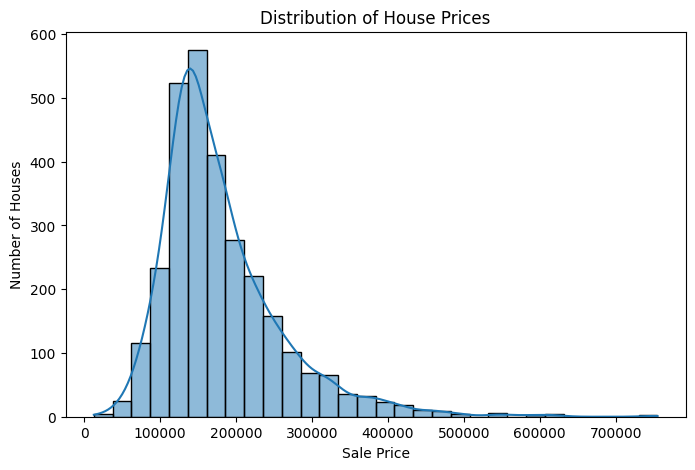

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(df['SalePrice'], bins=30, kde=True)

plt.xlabel('Sale Price')
plt.ylabel('Number of Houses')
plt.title('Distribution of House Prices')

plt.show()

### Distribution of SalePrice

The distribution of `SalePrice` is visualised using a histogram with a density curve.

The plot helps us understand how house prices are distributed across the dataset.

The distribution is right-skewed, meaning that most houses have lower to medium sale prices, while a smaller number of houses have very high sale prices.

## 3. Feature Selection

The following features are selected as predictors for the house price prediction model:

- **Overall Qual** – Represents the overall quality of the house. Higher-quality houses are generally expected to have higher sale prices.

- **Gr Liv Area** – Represents the above-ground living area. Larger living areas can contribute to higher house prices.

- **Garage Cars** – Represents the number of cars that can be accommodated in the garage. Garage capacity can influence property value.

- **Total Bsmt SF** – Represents the total basement area. A larger basement can contribute to the overall value of a property.

- **Year Built** – Represents the year in which the house was constructed and helps capture the effect of the property's age.

- **Full Bath** – Represents the number of full bathrooms. Houses with more bathrooms can have greater value.

- **Bedroom AbvGr** – Represents the number of bedrooms above ground and provides information about the size and functionality of the house.

- **Neighborhood** – Represents the location of the property. Location is an important factor in determining house prices and is a categorical feature that will be converted using One-Hot Encoding.

These features were selected because they represent important characteristics of a property, including quality, size, facilities, age and location. The selected features also include both numerical and categorical variables, allowing categorical data preprocessing to be demonstrated.

In [6]:
# Select features for the model

features = [
    'Overall Qual',
    'Gr Liv Area',
    'Garage Cars',
    'Total Bsmt SF',
    'Year Built',
    'Full Bath',
    'Bedroom AbvGr',
    'Neighborhood'
]

target = 'SalePrice'

model_data = df[features + [target]].copy()

print("Missing Values in Selected Features:")
print(model_data.isnull().sum())

Missing Values in Selected Features:
Overall Qual     0
Gr Liv Area      0
Garage Cars      1
Total Bsmt SF    1
Year Built       0
Full Bath        0
Bedroom AbvGr    0
Neighborhood     0
SalePrice        0
dtype: int64


In [7]:
# Separate numerical and categorical features

numeric_features = [
    'Overall Qual',
    'Gr Liv Area',
    'Garage Cars',
    'Total Bsmt SF',
    'Year Built',
    'Full Bath',
    'Bedroom AbvGr'
]

categorical_features = ['Neighborhood']

# Fill missing numerical values with the median
for column in numeric_features:
    model_data[column] = model_data[column].fillna(model_data[column].median())

# Fill missing categorical values with the mode
for column in categorical_features:
    model_data[column] = model_data[column].fillna(model_data[column].mode()[0])

print("Missing Values After Cleaning:")
print(model_data.isnull().sum())

Missing Values After Cleaning:
Overall Qual     0
Gr Liv Area      0
Garage Cars      0
Total Bsmt SF    0
Year Built       0
Full Bath        0
Bedroom AbvGr    0
Neighborhood     0
SalePrice        0
dtype: int64


# 4. Handling Missing Values

Missing values in the selected numerical features are replaced using the median value of each feature.

The median is used because it is less affected by extreme values than the mean.

For the categorical `Neighborhood` feature, missing values are replaced with the most frequent category (mode).

After this step, the selected features contain no missing values and are ready for encoding.

In [8]:
# One-Hot Encoding for categorical features

model_data_encoded = pd.get_dummies(
    model_data,
    columns=categorical_features,
    drop_first=True
)

print("Shape after One-Hot Encoding:", model_data_encoded.shape)

model_data_encoded.head()

Shape after One-Hot Encoding: (2930, 35)


,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,Year Built,Full Bath,Bedroom AbvGr,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,6,1656,2.0,1080.0,1960,1,3,215000,False,False,...,False,False,False,False,False,False,False,False,False,False
1,5,896,1.0,882.0,1961,1,2,105000,False,False,...,False,False,False,False,False,False,False,False,False,False
2,6,1329,1.0,1329.0,1958,1,3,172000,False,False,...,False,False,False,False,False,False,False,False,False,False
3,7,2110,2.0,2110.0,1968,2,3,244000,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,1629,2.0,928.0,1997,2,3,189900,False,False,...,False,False,False,False,False,False,False,False,False,False


## 5. One-Hot Encoding

The `Neighborhood` feature is categorical, so it cannot be directly used by a Linear Regression model.

One-Hot Encoding converts each neighborhood category into a separate binary column containing 0 or 1.

The `drop_first=True` option removes one category to avoid unnecessary redundancy between the encoded variables.

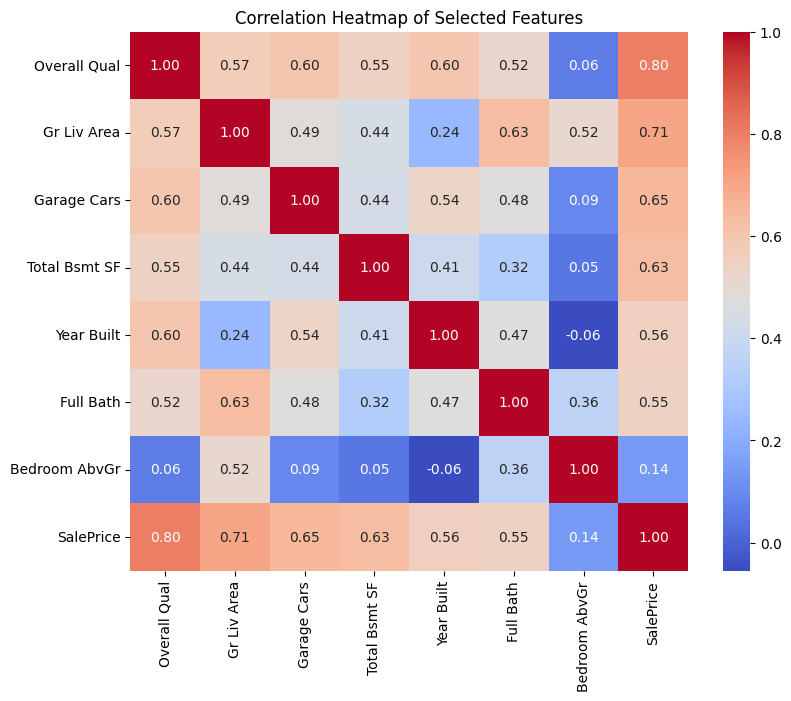

In [9]:
# Correlation between numerical features and SalePrice

correlation_data = model_data[
    numeric_features + [target]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Selected Features')
plt.show()

## 6. Correlation Heatmap

The correlation heatmap shows the relationship between the selected numerical features and `SalePrice`.

A positive correlation indicates that higher values of a feature are generally associated with higher house prices, while a negative correlation indicates an inverse relationship.

Among the selected features, `Overall Qual` and `Gr Liv Area` are expected to show strong positive relationships with `SalePrice`.

The `Neighborhood` feature is categorical, so its relationship with price is handled through One-Hot Encoding rather than the numerical correlation analysis.

In [12]:
# Separate features and target

X = model_data_encoded.drop('SalePrice', axis=1)
y = model_data_encoded['SalePrice']

# Split data into 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (2344, 34)
Testing Data: (586, 34)


## 7. Train/Test Split

The dataset is divided into training and testing sets using an 80/20 split.

- **80%** of the data is used to train the Linear Regression model.
- **20%** of the data is used to evaluate the model.

A random state of 42 is used so that the same split can be reproduced.

In [14]:
# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 8. Linear Regression Model

A Linear Regression model is trained using the selected house features.

The model learns the relationship between the input features and `SalePrice` from the training data.

After training, the model can be used to predict house prices for previously unseen test data.

In [16]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Squared Error (MSE): 1292793715.02
Root Mean Squared Error (RMSE): 35955.44
R² Score: 0.8388


## 9. Model Evaluation

The Linear Regression model is evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score.

- **MSE** measures the average squared difference between actual and predicted prices.
- **RMSE** represents the prediction error in the same units as the house price.
- **R² score** indicates how much of the variation in house prices is explained by the model.

A higher R² score and lower MSE/RMSE indicate better model performance.

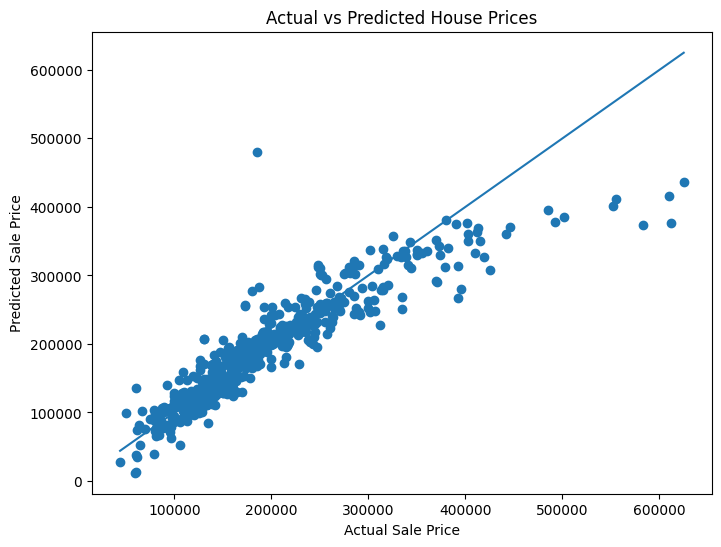

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Diagonal reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted House Prices')

plt.show()

## 10. Actual vs Predicted Prices

The scatter plot compares the actual house prices with the prices predicted by the Linear Regression model.

The diagonal line represents perfect predictions.

Points closer to the diagonal line indicate predictions that are closer to the actual house prices.

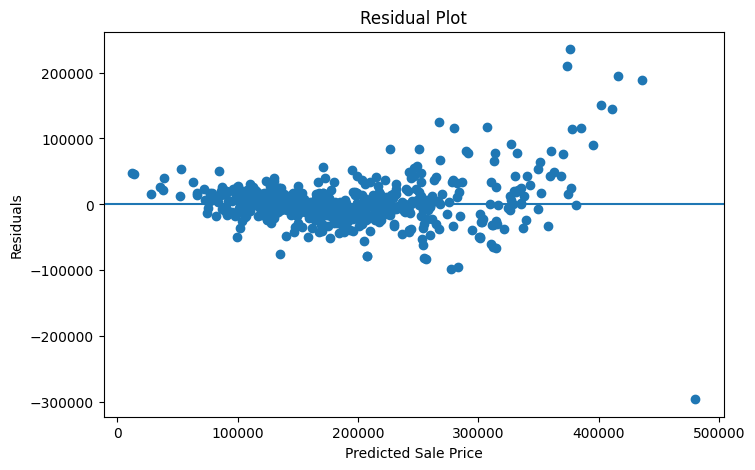

In [18]:
# Calculate residuals

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

## 11. Residual Plot

Residuals represent the difference between the actual and predicted house prices.

The residual plot is used to check whether the errors are randomly distributed around zero.

A good regression model should have residuals scattered around the zero line without a clear systematic pattern.

In [19]:
# Create a table of model coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# Sort coefficients from highest to lowest
coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
16,Neighborhood_GrnHill,114618.447396
31,Neighborhood_StoneBr,79384.229059
24,Neighborhood_NoRidge,66880.240064
25,Neighborhood_NridgHt,66030.156400
12,Neighborhood_Crawfor,41527.036745
10,Neighborhood_ClearCr,37041.067345
33,Neighborhood_Veenker,36653.223152
32,Neighborhood_Timber,35631.739383
30,Neighborhood_Somerst,25667.580896
11,Neighborhood_CollgCr,22149.495162


In [20]:
print("Top 5 Positive Coefficients:")
print(coefficients.head(5))

print("\nTop 5 Negative Coefficients:")
print(coefficients.tail(5))

Top 5 Positive Coefficients:
                 Feature    Coefficient
16  Neighborhood_GrnHill  114618.447396
31  Neighborhood_StoneBr   79384.229059
24  Neighborhood_NoRidge   66880.240064
25  Neighborhood_NridgHt   66030.156400
12  Neighborhood_Crawfor   41527.036745

Top 5 Negative Coefficients:
                 Feature   Coefficient
22  Neighborhood_NPkVill  -3714.691742
6          Bedroom AbvGr  -6165.668131
18  Neighborhood_Landmrk  -6218.085162
8    Neighborhood_BrDale -10924.274835
7   Neighborhood_Blueste -14050.168576


## 12. Coefficient Analysis

The coefficients represent the direction and estimated impact of each predictor on the predicted house price, while keeping the other model features constant.

- A **positive coefficient** indicates that an increase in the feature is associated with an increase in predicted house price.
- A **negative coefficient** indicates an inverse relationship with predicted house price.

The features with the largest positive and negative coefficients are examined to understand which predictors have the strongest influence on the model's predictions.

For the One-Hot Encoded `Neighborhood` variables, each coefficient represents the effect relative to the reference neighborhood that was removed during encoding.

In [21]:
from sklearn.linear_model import Ridge, Lasso

# Create Ridge and Lasso models
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.01, max_iter=10000)

# Train the models
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Make predictions
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

print("Ridge and Lasso models trained successfully.")

Ridge and Lasso models trained successfully.


## 13. Ridge and Lasso Regression

Ridge and Lasso are regularised versions of Linear Regression.

Regularisation adds a penalty to the model coefficients to reduce the risk of overfitting.

- **Ridge Regression** reduces the size of coefficients but generally keeps all features in the model.
- **Lasso Regression** can reduce some coefficients to zero, which can effectively remove less useful features.

These models are compared with the original Linear Regression model to determine which approach performs better on the test data.

In [22]:
# Calculate evaluation metrics for all three models

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

# Create comparison table
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MSE': [
        mse,
        ridge_mse,
        lasso_mse
    ],
    'RMSE': [
        rmse,
        ridge_rmse,
        lasso_rmse
    ],
    'R2 Score': [
        r2,
        ridge_r2,
        lasso_r2
    ]
})

model_comparison.round(2)

,Model,MSE,RMSE,R2 Score
0,Linear Regression,1.292794e+09,35955.44,0.84
1,Ridge Regression,1.292592e+09,35952.64,0.84
2,Lasso Regression,1.292790e+09,35955.39,0.84


## 14. Model Comparison

The performance of Linear Regression, Ridge Regression and Lasso Regression is compared using MSE, RMSE and R² score.

A lower MSE and RMSE indicate smaller prediction errors, while a higher R² score indicates that the model explains more variation in house prices.

The model with the best combination of low error and high R² score can be considered the better-performing model for this dataset.

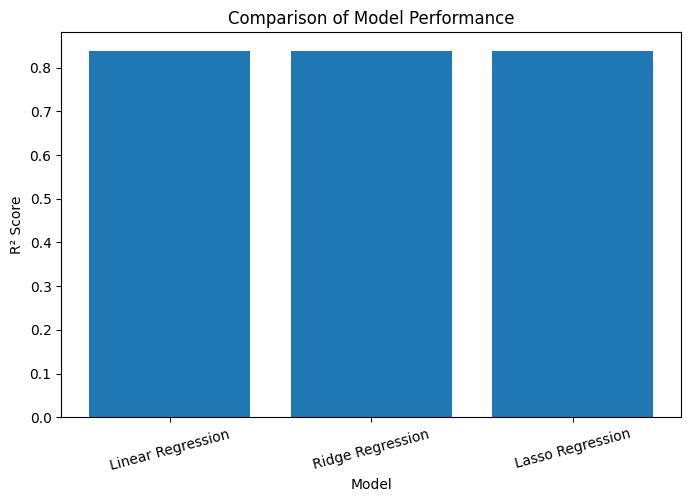

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison['Model'],
    model_comparison['R2 Score']
)

plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Comparison of Model Performance')

plt.xticks(rotation=15)

plt.show()

### R² Score Comparison

The bar chart compares the R² scores of the three regression models.

A higher R² score indicates better predictive performance on the test dataset.

The comparison helps determine whether regularisation using Ridge or Lasso improves the performance compared with standard Linear Regression.

# 15. Conclusion

A Linear Regression model was developed to predict house prices using selected property characteristics.

The dataset was explored and cleaned by handling missing values, and the categorical `Neighborhood` feature was converted into numerical variables using One-Hot Encoding.

The data was divided into training and testing sets using an 80/20 split. The Linear Regression model was evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score.

Actual versus predicted price and residual plots were used to visually examine model performance. Coefficient analysis was also performed to understand the positive and negative influence of the selected features.

As a bonus, Ridge and Lasso Regression models were trained and compared with the Linear Regression model. Their MSE, RMSE and R² scores were compared to determine whether regularisation improved predictive performance.

Overall, the project demonstrates an end-to-end machine learning workflow for house price prediction, including data exploration, preprocessing, feature selection, model training, evaluation and model interpretation.